In [4]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import scipy
import os

In [5]:
las_files = glob('/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files

['/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-30.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-26.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/ZTgl-1.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-15.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-29.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-8.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=docume

In [6]:
# Create a dictionary to store all DataFrames
las_dataframes = {}

for file_path in las_files:
    # Read the LAS file
    las_obj = las.read(file_path)
    
    # Convert to DataFrame
    df = las_obj.df()
    
    # Extract filename without extension (e.g., 'Tgl-30.las' -> 'Tgl-30')
    filename = os.path.basename(file_path)
    key_name = os.path.splitext(filename)[0]
    
    # Store in dictionary
    las_dataframes[key_name] = df
    
    print(f"Loaded: {key_name} - {len(df)} rows, {len(df.columns)} curves")

# Display the keys (well names) in the dictionary
print(f"\nTotal wells loaded: {len(las_dataframes)}")
print(f"Well names: {list(las_dataframes.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves

Total wells loaded: 7
Well names: ['Tgl-30', 'Tgl-26', 'ZTgl-1', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


In [7]:
def plot_well_logs(df, columns, well_name=None, figsize=None, depth_range=None):
    """
    Plot well log curves from a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with depth as index and log curves as columns
    columns : list
        List of column names to plot
    well_name : str, optional
        Name of the well for the title
    figsize : tuple, optional
        Figure size (width, height). Auto-calculated if None
    depth_range : tuple, optional
        (min_depth, max_depth) to limit the plot range
    
    Special columns:
    ----------------
    LITH : Lithology marker (discrete values 0-4)
    NAS : NAS marker (discrete values 0-5, 9)
    """
    # Marker columns that should be plotted as discrete/categorical
    marker_columns = ['LITH', 'NAS']
    
    # Color maps for marker columns
    lith_colors = {0: '#A9A9A9', 1: '#FFD700', 2: '#8B4513', 3: '#228B22', 4: '#4169E1'}
    nas_colors = {
        0: '#FFFFFF',    # white
        1: '#0000FF',    # blue
        2: '#8B4513',    # brown
        3: '#FFFF00',    # yellow
        4: '#90EE90',    # light-green
        5: '#006400',    # dark-green
        9: '#800080'     # purple
    }
    
    # Filter depth range if specified
    if depth_range is not None:
        df_plot = df.loc[depth_range[0]:depth_range[1]]
    else:
        df_plot = df
    
    depth = df_plot.index.values
    n_plots = len(columns)
    
    # Auto-calculate figure size
    if figsize is None:
        width = 2.5 * n_plots
        height = 12
        figsize = (width, height)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, sharey=True)
    if n_plots == 1:
        axes = [axes]
    
    fig.suptitle(f'Well: {well_name}' if well_name else 'Well Logs', fontsize=14, fontweight='bold')
    
    for ax, col in zip(axes, columns):
        if col not in df_plot.columns:
            ax.text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(col)
            continue
        
        data = df_plot[col].values
        
        if col in marker_columns:
            # Plot marker columns as filled discrete intervals
            ax.set_title(col, fontweight='bold')
            
            # Choose color map based on column
            color_map = lith_colors if col == 'LITH' else nas_colors
            
            # Plot as step function with colored fills
            unique_vals = np.unique(data[~np.isnan(data)])
            
            for val in unique_vals:
                if val in color_map:
                    mask = data == val
                    # Fill areas where this value occurs
                    ax.fill_betweenx(depth, 0, 1, where=mask, 
                                    color=color_map[val], alpha=0.8, 
                                    label=f'{int(val)}')
            
            ax.set_xlim(0, 1)
            ax.set_xticks([])
            ax.legend(loc='upper right', fontsize=8, title=col)
            
        else:
            # Plot regular log curves as lines
            ax.plot(data, depth, 'b-', linewidth=0.8)
            ax.set_title(col, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Auto-scale with some padding
            valid_data = data[~np.isnan(data)]
            if len(valid_data) > 0:
                vmin, vmax = np.nanmin(valid_data), np.nanmax(valid_data)
                padding = 0.1 * (vmax - vmin) if vmax > vmin else 1
                ax.set_xlim(vmin - padding, vmax + padding)
    
    # Set common y-axis
    axes[0].set_ylabel('Depth (m)', fontsize=12)
    axes[0].invert_yaxis()  # Depth increases downward
    
    plt.tight_layout()
    return fig, axes

(<Figure size 1250x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>,
        <Axes: title={'center': 'PL_GG'}>, <Axes: title={'center': 'DTP'}>,
        <Axes: title={'center': 'DTS'}>], dtype=object))

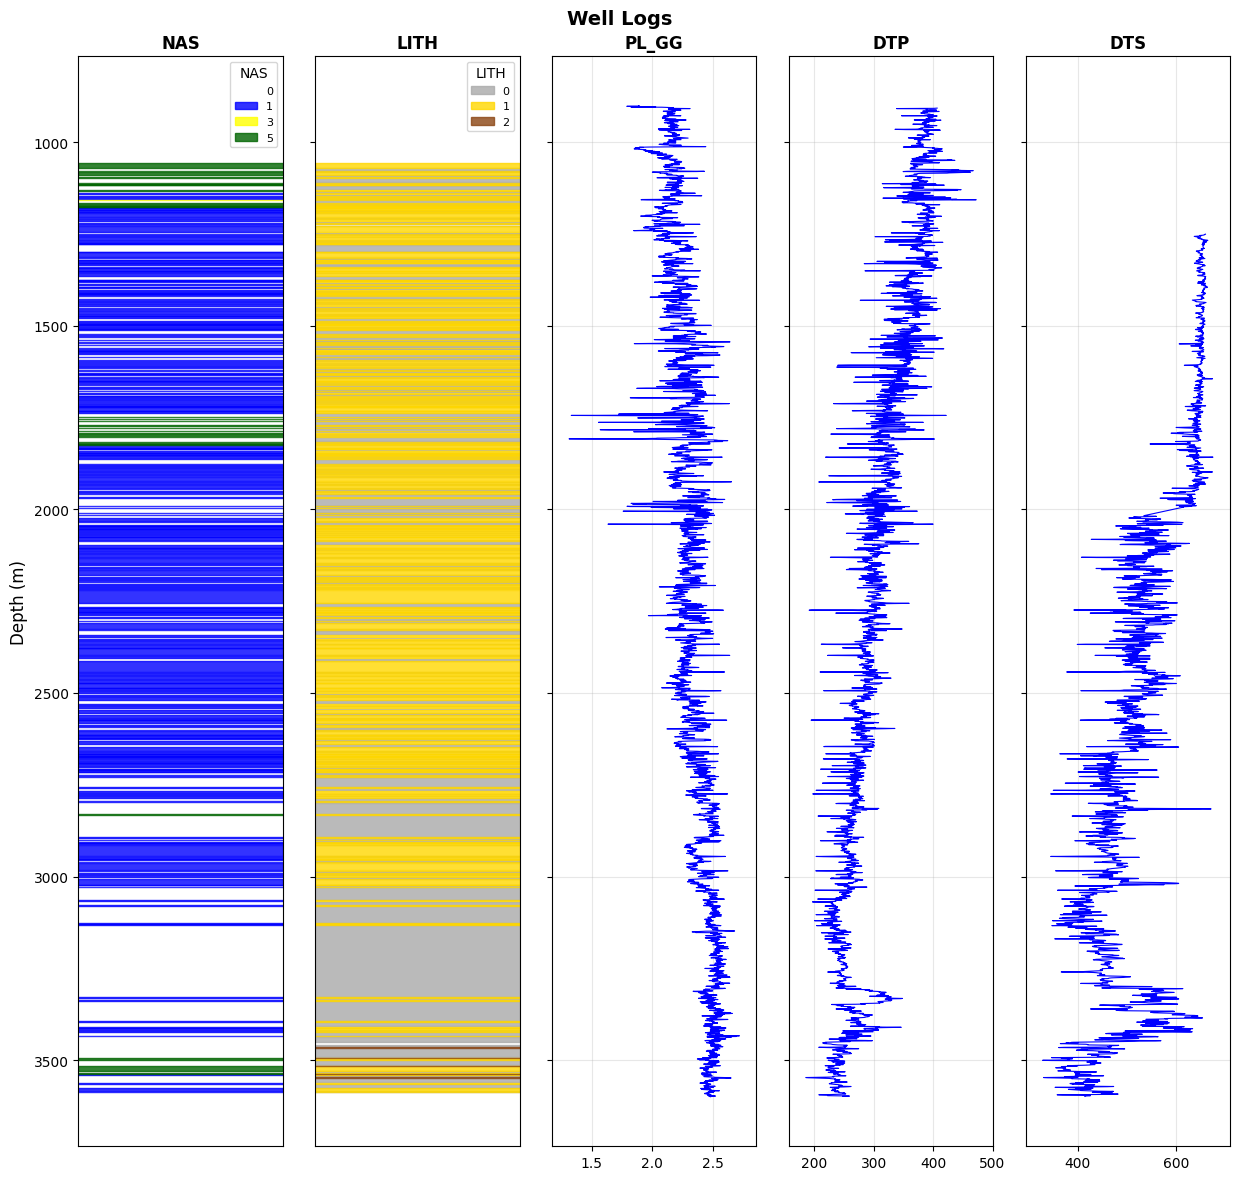

In [11]:
plot_well_logs(las_dataframes['Tgl-30'], ['NAS', 'LITH', 'PL_GG', 'DTP', 'DTS'])

In [9]:
las_dataframes['Tgl-30'].columns

Index(['ONE-WAYTIME1', 'GZ3', 'PZ', 'GR', 'NKTB', 'PS', 'BK', 'CALI', 'DTP',
       'DTS', 'PL_GG', 'DEPTH', 'LITH', 'NAS'],
      dtype='str')